# Adam: Exercise

For this exercise we will be build Adam up from scratch starting with regular gradient descent. We will also be utilizing mini batches to introduce stochasticity to the optimization. 

We will be working with the mnist_784 data set and a simple shallow neural network. 

If you do not have scikit-learn then you can get it here: https://scikit-learn.org/stable/install.html

This code is heavily inspired by Doug’s code from CSCI 447/547 lecture 05_multilayer_perceptron.

First we need to get the data, define the network and define some functions to perform on the data. You don’t need to do anything with this first block of code. 

In [1]:
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

# In order to run this in class, we're going to reduce the dataset by a factor of 5
X, y = fetch_openml('mnist_784', version=1, return_X_y=True)
X = X[::5]
y = y.astype(int)[::5]
X, X_test, y, y_test = train_test_split(X, y)

# Here we specify the size of our neural network.
# We are mapping from 784 to 10 with 256 hiden layer nodes.

m = len(X)
n_0 = 784
n_1 = 256
N = 10


# Function to convert categorical labels into one-hot matrix.
def convert_to_one_hot(y, n_classes):
    T = np.zeros((y.shape[0], n_classes))
    for t, yy in zip(T, y):
        t[yy] = 1
    return T


# Convert the data to one hot notation
one_hot_y_actual = convert_to_one_hot(y, N)
one_hot_y_test = convert_to_one_hot(y_test, N)


# Sigmoid function (activation)
def sigmoid(a):
    return 1. / (1 + np.exp(-a))


# Softmax function (final layer for classification)
def softmax(A):
    numerator = np.exp(A)
    denominator = numerator.sum(axis=1)
    return numerator / denominator[:, np.newaxis]


# Categorical cross-entropy
def L(T, S, W1, W2, alpha_1=1e-2, alpha_2=1e-5):
    return -1. / len(T) * np.sum(T * np.log(S)) + np.sum(0.5 * alpha_1 * W1 ** 2) + np.sum(0.5 * alpha_2 * W2 ** 2)


# Run the neural network forward, given some weights and biases
def feedforward(X, W1, W2, b1, b2):
    # Feedforward
    A1 = X @ W1 + b1
    Z1 = sigmoid(A1)
    A2 = Z1 @ W2 + b2
    y_pred = softmax(A2)
    return y_pred, Z1


# Compute the neural network gradients using backpropagation
def backpropogate(y_pred, Z1, X, y_obs, alpha_1=1e-2, alpha_2=1e-5):
    # Backpropogate
    delta_2 = (1. / len(y_pred)) * (y_pred - y_obs)
    grad_W2 = Z1.T @ delta_2 + alpha_2 * W2
    grad_b2 = delta_2.sum(axis=0)

    delta_1 = delta_2 @ W2.T * Z1 * (1 - Z1)
    grad_W1 = X.T @ delta_1 + alpha_1 * W1
    grad_b1 = delta_1.sum(axis=0)
    return grad_W1, grad_W2, grad_b1, grad_b2


def mini_batch(x_sample, y_sample, start_batch_size):
    """
    Takes a copy of x_sample and y_sample and returns mini batch matrices of both and number of batches
    """

    # Batches must divide evenly into total number of samples for numpy arrays to be happy.
    # Gets number of bathes by finding next smallest number that evenly divides
    num_batches = start_batch_size
    while len(x_sample) % num_batches != 0:
        num_batches -= 1

    # randomly shuffle indices
    np.random.seed(42)
    random_indices = np.random.choice(range(len(x_sample)), len(x_sample), replace=False)

    # instantiate lists to hold batches
    x_list = [[] for i in range(num_batches)]
    y_list = [[] for i in range(num_batches)]

    # populate batches matrix with random mini batch indices
    for i in range(len(x_sample)):

        x_list[i // 105].append(x_sample[random_indices[i]])
        y_list[i // 105].append(y_sample[random_indices[i]])
    
    # Convert to numpy arrays
    x_batch = np.array(x_list)
    y_batch = np.array(y_list)

    return x_batch, y_batch, num_batches, num_batches


# Vanilla Gradient Descent

For our first exercise we will implement plain old gradient descent. The mathematical formula is:

$$ \theta_t = \theta_{t-1} - \alpha \nabla f(\theta_{t-1}) \tag{1}$$
---

We have already specified initial values for the $\alpha$ and the batch size but feel free to play around with it. The location to insert your gradient descent implementation is outlined with a multi-line comment.  

In [2]:
"""
Vanilla Gradient Descent
"""

# Hyper Parameters
eta = 1e-5
initial_batch_size = 104
epochs = 250

# Initialize random parameter matrices
np.random.seed(42)
W1 = 0.001 * np.random.randn(n_0, n_1)
W2 = 0.001 * np.random.randn(n_1, N)

b1 = 0.1 * np.random.randn(1, n_1)
b2 = 0.1 * np.random.randn(1, N)

# data for analysis
vanilla_loss = []

# Perform gradient descent
for i in range(epochs):

    # generate mini batches
    x_batches, y_batches, num_batches, actual_batch_size = mini_batch(X, one_hot_y_actual, initial_batch_size)

    # perform gradient descent on mini batches
    for j in range(num_batches):
        y_pred, Z1 = feedforward(x_batches[j], W1, W2, b1, b2)
        
        """
        These are your gradients with respect to weight matrices W1 and W2 
        as well as your biases b1 and b2
        """
        grad_W1, grad_W2, grad_b1, grad_b2 = backpropogate(y_pred, Z1, x_batches[j], y_batches[j])

        """
        You put your code here. W1 and W2 are your weight matrices.
        b1 and b2 are your bias for each matrix.
        Each are numpy arrays.
        """
        W1 -= eta*grad_W1
        W2 -= eta*grad_W2
        b1 -= eta*grad_b1
        b2 -= eta*grad_b2


    # calc loss at end of each epoch
    y_entire_pred, Z1 = feedforward(X, W1, W2, b1, b2)
    vanilla_loss.append(L(one_hot_y_actual, y_entire_pred, W1, W2))

    # Print some summary statistics every ten iterations
    if i % 10 == 0:
        y_pred_test, Z1_test = feedforward(X_test, W1, W2, b1, b2)
        acc = sum(y_test == np.argmax(y_pred_test, axis=1)) / len(y_test)
        y_entire_pred, Z1 = feedforward(X, W1, W2, b1, b2)
        print("Epoch %d Loss %f Accuracy %f" % (i, L(one_hot_y_actual, y_entire_pred, W1, W2), acc))


Epoch 0 Loss 2.304874 Accuracy 0.083429
Epoch 10 Loss 2.295990 Accuracy 0.083429
Epoch 20 Loss 2.286508 Accuracy 0.083429
Epoch 30 Loss 2.275956 Accuracy 0.106571
Epoch 40 Loss 2.264063 Accuracy 0.163429
Epoch 50 Loss 2.250664 Accuracy 0.188286
Epoch 60 Loss 2.235691 Accuracy 0.269143
Epoch 70 Loss 2.219173 Accuracy 0.395429
Epoch 80 Loss 2.201226 Accuracy 0.523429
Epoch 90 Loss 2.182004 Accuracy 0.595143
Epoch 100 Loss 2.161669 Accuracy 0.623429
Epoch 110 Loss 2.140389 Accuracy 0.635429
Epoch 120 Loss 2.118330 Accuracy 0.638571
Epoch 130 Loss 2.095644 Accuracy 0.638857
Epoch 140 Loss 2.072467 Accuracy 0.634571
Epoch 150 Loss 2.048914 Accuracy 0.630286
Epoch 160 Loss 2.025092 Accuracy 0.626857
Epoch 170 Loss 2.001112 Accuracy 0.628286
Epoch 180 Loss 1.977068 Accuracy 0.630286
Epoch 190 Loss 1.953025 Accuracy 0.630571
Epoch 200 Loss 1.929042 Accuracy 0.633143
Epoch 210 Loss 1.905168 Accuracy 0.635429
Epoch 220 Loss 1.881447 Accuracy 0.639143
Epoch 230 Loss 1.857912 Accuracy 0.642000
Epo

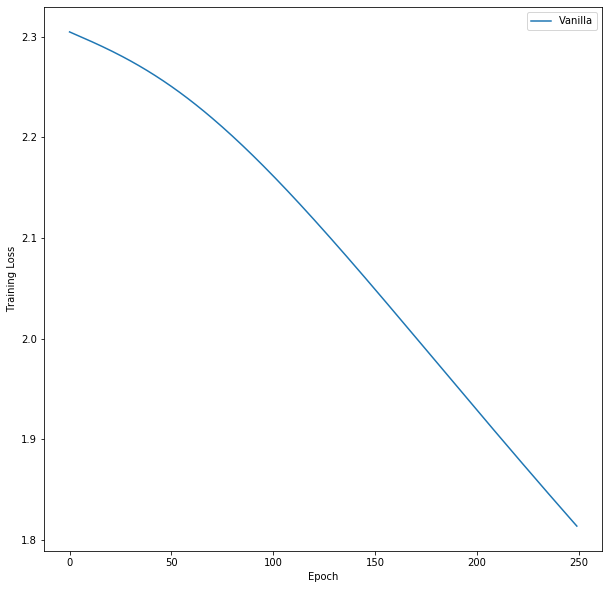

In [4]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (10,10)

plt.plot(vanilla_loss, label='Vanilla')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.show()

# Momentum Gradient Descent

Next we will add momentum. The the new update rule is:

$$m_{t}=\beta_{1} m_{t-1} + (1 - \beta_{1})\nabla f(\theta_{t-1})$$
---

$$ \beta_1 \in [0,1)$$
---

$$\theta_{t}=\theta_{t-1} - \alpha m_{t} \tag{2}$$
---

In [15]:

"""
Momentum Gradient Descent
"""

# Hyper Parameters
eta = 1e-5
initial_batch_size = 104
epochs = 250
"""
You need to add another hyper parameter here. Hint! look at the equation above
"""
beta_1 = .999
# data for analysis
momentum_loss = []

# Initialize random parameter matrices
np.random.seed(42)
W1 = 0.001 * np.random.randn(n_0, n_1)
W2 = 0.001 * np.random.randn(n_1, N)

b1 = 0.1 * np.random.randn(1, n_1)
b2 = 0.1 * np.random.randn(1, N)

"""
You probably need to initialize your momentum here... 
"""
m_w1 = np.zeros((n_0,n_1))
m_w2 = np.zeros((n_1,N))
m_b1 = np.zeros((1,n_1))
m_b2 = np.zeros((1,N))


# Perform gradient descent
for i in range(epochs):

    # generate mini batches
    x_batches, y_batches, num_batches, actual_batch_size = mini_batch(X, one_hot_y_actual, initial_batch_size)

    # perform gradient descent on mini batches
    for j in range(num_batches):
        y_pred, Z1 = feedforward(x_batches[j], W1, W2, b1, b2)

        """
        These are your gradients with respect to weight matrices W1 and W2 
        as well as your biases b1 and b2
        """
        grad_W1, grad_W2, grad_b1, grad_b2 = backpropogate(y_pred, Z1, x_batches[j], y_batches[j])

        """
        You put your code here. W1 and W2 are your weight matrices.
        b1 and b2 are your bias for each matrix.
        Each are numpy arrays.
        """
        m_w1 = beta_1*m_w1 + (1-beta_1)*grad_W1
        m_w2 = beta_1*m_w2 + (1-beta_1)*grad_W2
        m_b1 = beta_1*m_b1 + (1-beta_1)*grad_b1
        m_b2 = beta_1*m_b2 + (1-beta_1)*grad_b2
        
        W1 -= eta*m_w1
        W2 -= eta*m_w2
        b1 -= eta*m_b1
        b2 -= eta*m_b2
        
    # calc loss at end of each epoch
    y_entire_pred, Z1 = feedforward(X, W1, W2, b1, b2)
    momentum_loss.append(L(one_hot_y_actual, y_entire_pred, W1, W2))

    # Print some summary statistics every ten iterations
    if i % 10 == 0:
        y_pred_test, Z1_test = feedforward(X_test, W1, W2, b1, b2)
        acc = sum(y_test == np.argmax(y_pred_test, axis=1)) / len(y_test)
        y_entire_pred, Z1 = feedforward(X, W1, W2, b1, b2)
        print("Epoch %d Loss %f Accuracy %f" % (i, L(one_hot_y_actual, y_entire_pred, W1, W2), acc))


Epoch 0 Loss 2.305713 Accuracy 0.083429
Epoch 10 Loss 2.301940 Accuracy 0.083429
Epoch 20 Loss 2.295031 Accuracy 0.083429
Epoch 30 Loss 2.286848 Accuracy 0.083429
Epoch 40 Loss 2.277756 Accuracy 0.093429
Epoch 50 Loss 2.267628 Accuracy 0.159429
Epoch 60 Loss 2.256275 Accuracy 0.184571
Epoch 70 Loss 2.243567 Accuracy 0.240286
Epoch 80 Loss 2.229440 Accuracy 0.331714
Epoch 90 Loss 2.213896 Accuracy 0.457714
Epoch 100 Loss 2.197008 Accuracy 0.556571
Epoch 110 Loss 2.178896 Accuracy 0.606000
Epoch 120 Loss 2.159686 Accuracy 0.625429
Epoch 130 Loss 2.139507 Accuracy 0.631429
Epoch 140 Loss 2.118500 Accuracy 0.633143
Epoch 150 Loss 2.096802 Accuracy 0.631429
Epoch 160 Loss 2.074542 Accuracy 0.626857
Epoch 170 Loss 2.051839 Accuracy 0.623143
Epoch 180 Loss 2.028799 Accuracy 0.621143
Epoch 190 Loss 2.005515 Accuracy 0.623714
Epoch 200 Loss 1.982069 Accuracy 0.624571
Epoch 210 Loss 1.958534 Accuracy 0.626286
Epoch 220 Loss 1.934986 Accuracy 0.627714
Epoch 230 Loss 1.911493 Accuracy 0.630571
Epo

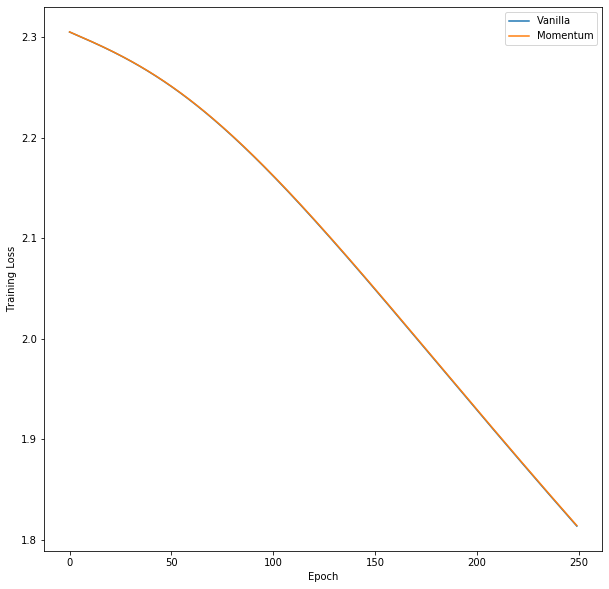

In [14]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (10,10)

plt.plot(vanilla_loss, label='Vanilla')
plt.plot(momentum_loss, label='Momentum')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.show()

# RMSProp Gradient Descent 

Next we will do RMSProp. The update rule is as follows:

$$v_{t} = \beta_{2}v_{t-1} + (1 - \beta_{2})\nabla f(\theta_{t-1})^2$$
---

$$ \beta_2 \in [0,1)$$
---

$$\theta_{t} = \theta_{t-1} - \alpha \frac { \nabla f(\theta_{t-1})}{\sqrt{v_{t} + \epsilon}} \tag{3}$$ 
---


In [16]:
"""
RMSProp Gradient Descent
"""

# Hyper Parameters
eta = 1e-5
initial_batch_size = 104
epochs = 250
"""
You need to add two hyper parameters here. Hint! look at the equation above
"""
beta_2 = .999
epsilon = 1e-8

# Initialize random parameter matrices
np.random.seed(42)
W1 = 0.001 * np.random.randn(n_0, n_1)
W2 = 0.001 * np.random.randn(n_1, N)

b1 = 0.1 * np.random.randn(1, n_1)
b2 = 0.1 * np.random.randn(1, N)

# data for analysis
RMS_loss = []

"""
You probably need to initialize your variance here...
"""
v_w1 = np.zeros((n_0,n_1))
v_w2 = np.zeros((n_1,N))
v_b1 = np.zeros((1,n_1))
v_b2 = np.zeros((1,N))

# Perform gradient descent
for i in range(epochs):

    # generate mini batches
    x_batches, y_batches, num_batches, actual_batch_size = mini_batch(X, one_hot_y_actual, initial_batch_size)

    # perform gradient descent on mini batches
    for j in range(num_batches):
        y_pred, Z1 = feedforward(x_batches[j], W1, W2, b1, b2)

        """
        These are your gradients with respect to weight matrices W1 and W2 
        as well as your biases b1 and b2
        """
        grad_W1, grad_W2, grad_b1, grad_b2 = backpropogate(y_pred, Z1, x_batches[j], y_batches[j])

        """
        You put your code here. W1 and W2 are your weight matrices.
        b1 and b2 are your bias for each matrix.
        Each are numpy arrays.
        """
        
        v_w1 = beta_2*v_w1 + (1-beta_2)*grad_W1**2
        v_w2 = beta_2*v_w2 + (1-beta_2)*grad_W2**2
        v_b1 = beta_2*v_b1 + (1-beta_2)*grad_b1**2
        v_b2 = beta_2*v_b2 + (1-beta_2)*grad_b2**2
        
        W1 -= eta*(grad_W1/np.sqrt(v_w1+epsilon))
        W2 -= eta*(grad_W2/np.sqrt(v_w2+epsilon))
        b1 -= eta*(grad_b1/np.sqrt(v_b1+epsilon))
        b2 -= eta*(grad_b2/np.sqrt(v_b2+epsilon))

       

    # calc loss at end of each epoch
    y_entire_pred, Z1 = feedforward(X, W1, W2, b1, b2)
    RMS_loss.append(L(one_hot_y_actual, y_entire_pred, W1, W2))

    # Print some summary statistics every ten iterations
    if i % 10 == 0:
        y_pred_test, Z1_test = feedforward(X_test, W1, W2, b1, b2)
        acc = sum(y_test == np.argmax(y_pred_test, axis=1)) / len(y_test)
        y_entire_pred, Z1 = feedforward(X, W1, W2, b1, b2)
        print("Epoch %d Loss %f Accuracy %f" % (i, L(one_hot_y_actual, y_entire_pred, W1, W2), acc))


Epoch 0 Loss 1.793033 Accuracy 0.801143
Epoch 10 Loss 0.913911 Accuracy 0.891429
Epoch 20 Loss 0.633606 Accuracy 0.900571
Epoch 30 Loss 0.479382 Accuracy 0.904857
Epoch 40 Loss 0.380321 Accuracy 0.909143
Epoch 50 Loss 0.311572 Accuracy 0.914857
Epoch 60 Loss 0.261716 Accuracy 0.915429
Epoch 70 Loss 0.224133 Accuracy 0.918857
Epoch 80 Loss 0.194874 Accuracy 0.921143
Epoch 90 Loss 0.171643 Accuracy 0.921429
Epoch 100 Loss 0.152986 Accuracy 0.920286
Epoch 110 Loss 0.137780 Accuracy 0.920286
Epoch 120 Loss 0.125181 Accuracy 0.921143
Epoch 130 Loss 0.114418 Accuracy 0.922286
Epoch 140 Loss 0.105092 Accuracy 0.923429
Epoch 150 Loss 0.096992 Accuracy 0.924000
Epoch 160 Loss 0.089864 Accuracy 0.925143
Epoch 170 Loss 0.083522 Accuracy 0.925714
Epoch 180 Loss 0.077868 Accuracy 0.925143
Epoch 190 Loss 0.072839 Accuracy 0.926286
Epoch 200 Loss 0.068406 Accuracy 0.926571
Epoch 210 Loss 0.064380 Accuracy 0.927714
Epoch 220 Loss 0.060776 Accuracy 0.928000
Epoch 230 Loss 0.057455 Accuracy 0.927429
Epo

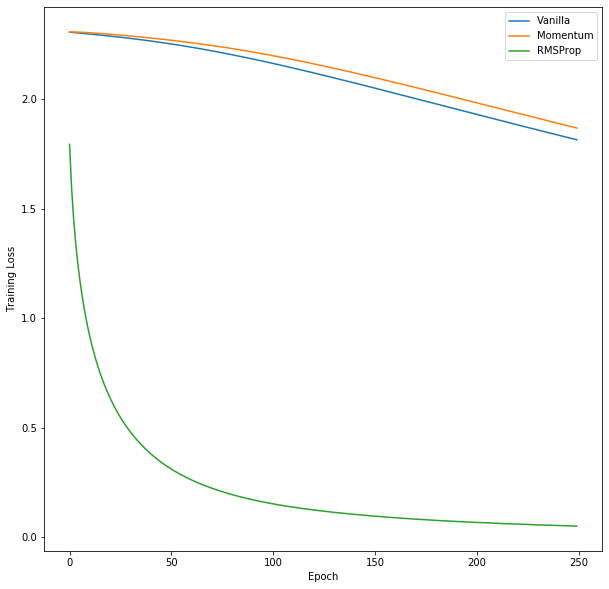

In [17]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (10,10)

plt.plot(vanilla_loss, label='Vanilla')
plt.plot(momentum_loss, label='Momentum')
plt.plot(RMS_loss, label='RMSProp')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.show()

# Adam Gradient Descent 

Now we put them both together and we get Adam!

$$m_{t}=\beta_{1} m_{t-1} + (1 - \beta_{1})\nabla f(\theta_{t-1})$$
---

$$v_{t} = \beta_{2}v_{t-1} + (1 - \beta_{2})\nabla f(\theta_{t-1})^2$$
---

$$\hat m_{t} = \frac {m_{t}}{1 - \beta_1^{t}}$$
---

$$\hat v_t = \frac {v_{t}}{1 - \beta_2^{t}}$$
---

$$\theta_t = \theta_{t-1} - \alpha \frac {\hat m_t}{\sqrt{\hat v_t + \epsilon}} \tag{4}$$
---

Play around with the hyperparameters to see if you can get distinctly different behavior from the optimization.

In [21]:
"""
Adam Gradient Descent
"""

# Hyper Parameters
eta = 1e-4
initial_batch_size = 104
epochs = 250
"""
You need to add 3 hyper parameters here. Hint! look at the equation above
"""
beta_1 = .9
beta_2 = .999
epsilon = 1e-8
t = 0
# Initialize random parameter matrices
np.random.seed(42)
W1 = 0.001 * np.random.randn(n_0, n_1)
W2 = 0.001 * np.random.randn(n_1, N)

b1 = 0.1 * np.random.randn(1, n_1)
b2 = 0.1 * np.random.randn(1, N)

# data for analysis
Adam_loss = []

"""
You probably need to initialize your variance and momentum here...
"""
v_w1 = np.zeros((n_0,n_1))
v_w2 = np.zeros((n_1,N))
v_b1 = np.zeros((1,n_1))
v_b2 = np.zeros((1,N))

m_w1 = np.zeros((n_0,n_1))
m_w2 = np.zeros((n_1,N))
m_b1 = np.zeros((1,n_1))
m_b2 = np.zeros((1,N))
# Perform gradient descent
for i in range(epochs):

    # generate mini batches
    x_batches, y_batches, num_batches, actual_batch_size = mini_batch(X, one_hot_y_actual, initial_batch_size)

    # perform gradient descent on mini batches
    for j in range(num_batches):
        y_pred, Z1 = feedforward(x_batches[j], W1, W2, b1, b2)

        """
        These are your gradients with respect to weight matrices W1 and W2 
        as well as your biases b1 and b2
        """
        grad_W1, grad_W2, grad_b1, grad_b2 = backpropogate(y_pred, Z1, x_batches[j], y_batches[j])

        """
        You put your code here. W1 and W2 are your weight matrices.
        b1 and b2 are your bias for each matrix.
        Each are numpy arrays.
        """
        t += 1
        
        m_w1 = beta_1*m_w1 + (1-beta_1)*grad_W1
        m_w2 = beta_1*m_w2 + (1-beta_1)*grad_W2
        m_b1 = beta_1*m_b1 + (1-beta_1)*grad_b1
        m_b2 = beta_1*m_b2 + (1-beta_1)*grad_b2
        
        mhat_w1 = m_w1/(1-beta_1**(t)) 
        mhat_w2 = m_w2/(1-beta_1**(t))
        mhat_b1 = m_b1/(1-beta_1**(t)) 
        mhat_b2 = m_b2/(1-beta_1**(t)) 

        v_w1 = beta_2*v_w1 + (1-beta_2)*grad_W1**2
        v_w2 = beta_2*v_w2 + (1-beta_2)*grad_W2**2
        v_b1 = beta_2*v_b1 + (1-beta_2)*grad_b1**2
        v_b2 = beta_2*v_b2 + (1-beta_2)*grad_b2**2
        
        vhat_w1 = v_w1/(1-beta_2**(t)) 
        vhat_w2 = v_w2/(1-beta_2**(t))
        vhat_b1 = v_b1/(1-beta_2**(t)) 
        vhat_b2 = v_b2/(1-beta_2**(t))            
        
        W1 -= eta*(mhat_w1/np.sqrt(vhat_w1+epsilon))
        W2 -= eta*(mhat_w2/np.sqrt(vhat_w2+epsilon))
        b1 -= eta*(mhat_b1/np.sqrt(vhat_b1+epsilon))
        b2 -= eta*(mhat_b2/np.sqrt(vhat_b2+epsilon))        

    # calc loss at end of each epoch
    y_entire_pred, Z1 = feedforward(X, W1, W2, b1, b2)
    Adam_loss.append(L(one_hot_y_actual, y_entire_pred, W1, W2))

    # Print some summary statistics every ten iterations
    if i % 10 == 0:
        y_pred_test, Z1_test = feedforward(X_test, W1, W2, b1, b2)
        acc = sum(y_test == np.argmax(y_pred_test, axis=1)) / len(y_test)
        y_entire_pred, Z1 = feedforward(X, W1, W2, b1, b2)
        print("Epoch %d Loss %f Accuracy %f" % (i, L(one_hot_y_actual, y_entire_pred, W1, W2), acc))


Epoch 0 Loss 1.522062 Accuracy 0.848286
Epoch 10 Loss 0.260011 Accuracy 0.915143
Epoch 20 Loss 0.157128 Accuracy 0.924286
Epoch 30 Loss 0.113172 Accuracy 0.927143
Epoch 40 Loss 0.085140 Accuracy 0.930571
Epoch 50 Loss 0.067600 Accuracy 0.932286
Epoch 60 Loss 0.054346 Accuracy 0.930857
Epoch 70 Loss 0.041985 Accuracy 0.935714
Epoch 80 Loss 0.043293 Accuracy 0.937429
Epoch 90 Loss 0.024500 Accuracy 0.937143
Epoch 100 Loss 0.017696 Accuracy 0.937429
Epoch 110 Loss 0.052001 Accuracy 0.950571
Epoch 120 Loss 0.027004 Accuracy 0.948857
Epoch 130 Loss 0.018313 Accuracy 0.946286
Epoch 140 Loss 0.013187 Accuracy 0.946857
Epoch 150 Loss 0.052697 Accuracy 0.951714
Epoch 160 Loss 0.023928 Accuracy 0.954571
Epoch 170 Loss 0.016007 Accuracy 0.955429
Epoch 180 Loss 0.011239 Accuracy 0.953714
Epoch 190 Loss 0.062404 Accuracy 0.951143
Epoch 200 Loss 0.022761 Accuracy 0.958286
Epoch 210 Loss 0.015271 Accuracy 0.958286
Epoch 220 Loss 0.010855 Accuracy 0.958857
Epoch 230 Loss 0.222940 Accuracy 0.914857
Epo

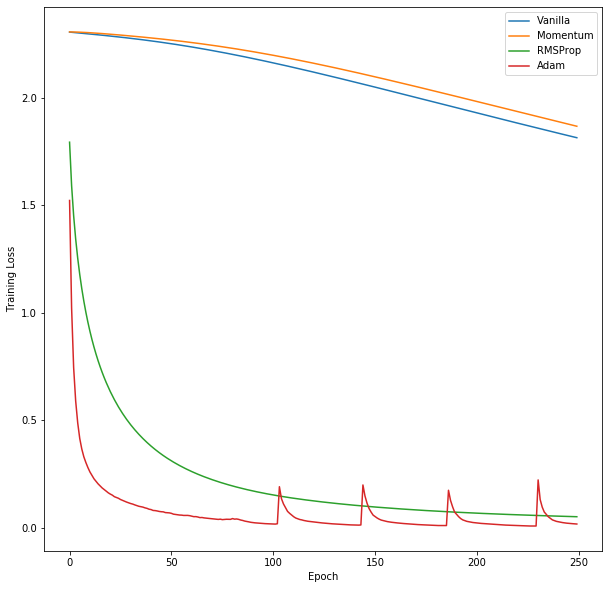

In [22]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (10,10)

plt.plot(vanilla_loss, label='Vanilla')
plt.plot(momentum_loss, label='Momentum')
plt.plot(RMS_loss, label='RMSProp')
plt.plot(Adam_loss, label='Adam')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.show()